# Understanding the Roman WFI Pixel Area Reference File

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.
    

## Introduction
The purpose of this notebook is to understand the content and purpose of the **Pixel Area** (`AREA`) reference file.

The AREA reference file provides the pixel area in steradians for each pixel. It is used during photometric calibration to correctly convert surface brightness to flux, especially important for extended sources. 

More details about this and other reference files can be found in the [Reference File Information](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/index.html).

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide important information about setting up your environment and installing dependencies.

## Imports
Libraries used:
- *os* for operating system functions
- *astropy* for image normalization
- *copy* for making copies of Python objects
- *crds* for access to calibration reference files
- *matplotlib* and *mpl_toolkits* for plotting images
- *numpy* for array manipulation
- *roman_datamodels* for opening Roman WFI ASDF files

In [1]:
import os
from astropy.visualization import simple_norm
import copy

import matplotlib.pyplot as plt
from matplotlib import colors, colormaps as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import roman_datamodels as rdm

### The Calibration Reference Data System (CRDS)

The reference files, developed and validated by STScI’s Science Operations Center, are continually updated as new WFI data become available. For more information about how CRDS works and how it assigns the most appropriate reference file for each calibration step, refer to the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb). 

**IMPORTANT NOTE:** Reference files are a work in progress and will be updated several times before Roman launch. If you notice irregularities or missing information, please understand that they may be a known issue. If you have questions, please contact the [Roman Help Desk](https://romanhelp.stsci.edu).

In [2]:
import crds

Now let's dive into this reference file type.

### Pixel Area Reference File

The AREA reference file contains the solid angle (in steradians) subtended by each pixel. It is used in the photometric calibration step to properly handle extended sources.

Before proceeding, let's check the environmental variables set for CRDS

In [3]:
print(f"CRDS server location: {os.environ.get('CRDS_SERVER_URL')}")
print(f"CRDS context file: {os.environ.get('CRDS_CONTEXT')}")

CRDS server location: https://roman-crds.stsci.edu
CRDS context file: roman-edit


If we want to change the context, we can do it in the next cell. In this case, we choose context `roman_0055.pmap`.

In [4]:
os.environ['CRDS_CONTEXT']='roman_0055.pmap'

### Retrieving Reference Files

As you run the exposure pipeline, the most up-to-date reference files will be automatically selected for each step. However, if you would like to use a specific reference file, retrieve it using the `CRDS` Python API and feed it to the Exposure Level or Mosaic Pipeline, see the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb) for more details. 

For the area reference files in particular, the keywords that will identify the best reference file to use are:

- ROMAN.META.INSTRUMENT.NAME
- ROMAN.META.INSTRUMENT.DETECTOR
- ROMAN.META.EXPOSURE.START_TIME

These keywords may be combined into a single dictionary to find and download the file using `crds.getreferences()`.  

In [5]:
meta = {'ROMAN.META.INSTRUMENT.NAME': 'WFI',
        'ROMAN.META.INSTRUMENT.DETECTOR': 'WFI01',
        'ROMAN.META.EXPOSURE.START_TIME': '2026-01-01 00:00:00'
       }

ref_files = crds.getreferences(meta, reftypes=['area'], observatory='roman')
ref_files

{'area': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_area_0009.asdf'}

### Examining Reference Files

Reference files use `roman_datamodels` just like WFI science data products and can be accessed in the same way (see the tutorial [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb) for more information). Let's take a closer look at the files we retrieved from our `crds.getreferences()` example:

In [6]:
area = rdm.open(ref_files['area'])
area.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 4.1.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   ├─1 (ExtensionMetadata) ...
│   └─2 (ExtensionMetadata) ...
└─roman (PixelareaRef) # Pixel Area Reference Schema
  ├─meta (AsdfDictNode)
  │ ├─author (str): Tyler Desjardins # Author
  │ ├─description (str): Roman WFI pixel area map. # Description
  │ ├─instrument (AsdfDictNode) ...
  │ ├─origin (Origin): STSCI/SOC # Institution / Organization Name
  │ ├─pedigree (str): GROUND # Pedigree
  │ ├─photometry (AsdfDictNode) ...
  │ ├─reftype (str): AREA
  │ ├─telescope (Telescope): ROMAN # Telescope Name
  │ └─useafter (Time): 2020-01-01 00:00:00 # Use After Date
  └─data (NDArrayType) # Pixel Area Array ...
Some nodes not shown.


The AREA reference file is typically a 2D array with pixel solid angle values in steradians.

### Basic Statistics

Now lets get some basic statistics on the cube (or a representative slice)

In [7]:
print("Area array shape:", area.data.shape)
print("\nPixel area statistics (steradians):")
print(f"  Min: {area.data.min():.2e}")
print(f"  Max: {area.data.max():.2e}")
print(f"  Mean: {area.data.mean():.2e}")
print(f"  Median: {np.median(area.data):.2e}")
print(f"  Std: {area.data.std():.2e}")

Area array shape: (4088, 4088)

Pixel area statistics (steradians):
  Min: 9.86e-01
  Max: 1.01e+00
  Mean: 1.00e+00
  Median: 1.00e+00
  Std: 6.18e-03


### Visualization

Let's check this reference file

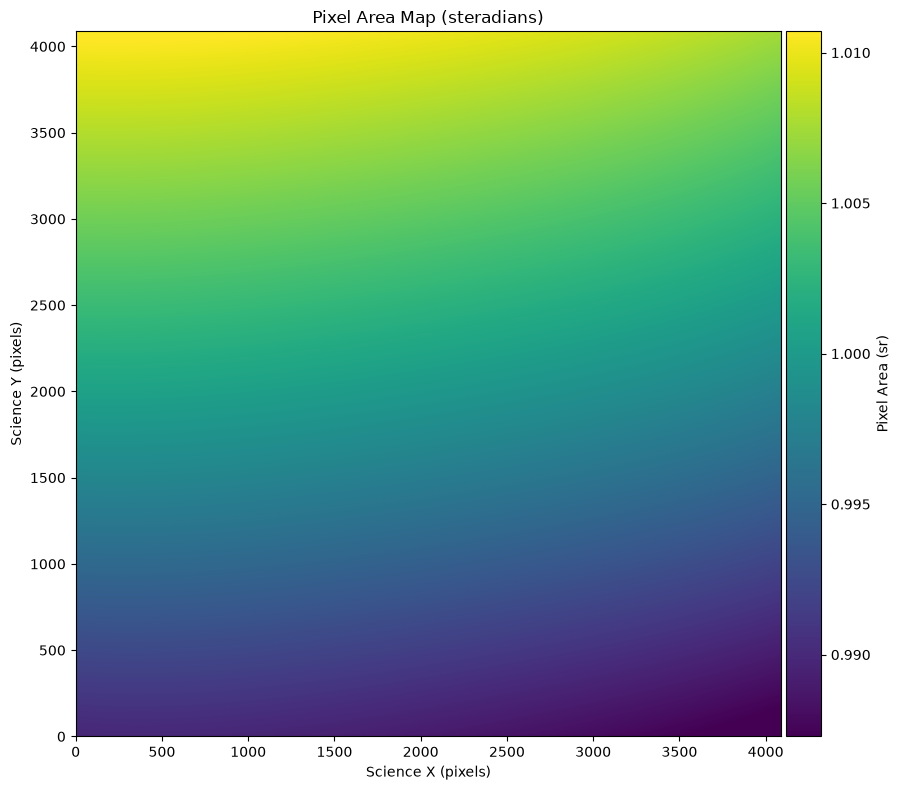

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

my_cmap = copy.copy(cm.get_cmap('viridis'))
my_cmap.set_bad('black')

norm = simple_norm(area.data, stretch='linear', percent=99.5)
im = ax.imshow(area.data, cmap=my_cmap, norm=norm, origin='lower')
ax.set_title('Pixel Area Map (steradians)')
ax.set_xlabel('Science X (pixels)')
ax.set_ylabel('Science Y (pixels)')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label='Pixel Area (sr)')

plt.tight_layout()
plt.show()

## About this Notebook
**Author:** R. Diaz

**Updated On:** 2026-07-06

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>